
# Triadic Cell Notebook v30
## Soft Nyquist score + directional complement

This notebook fixes the v29 failure mode.

v29 got the geometry right:
- missing is a directional complement shape
- retrieve is a declaration-permission field

But the Nyquist gate was too hard and zeroed out the entire retrieve branch. In the uploaded v29 run:
- `retrieve_fraction = 0.0`
- `grow_fraction = 1.0`
- `nyquist_pass_fraction = 0.0`
- `retrieve_case_retrieve_mode_rate = 0.0`
- `grow_case_grow_mode_rate = 1.0` fileciteturn66file8turn66file12

So v30 keeps the Pythagorean split and replaces the hard Nyquist gate with a **soft Nyquist score**.

## The fix

Instead of:

$$
N_{\text{active}} \ge 2 B_{\text{candidate}}
$$

we use a soft score:

$$
\eta = \frac{N_{\text{active}}}{B_{\text{eff}}}
$$

with

$$
B_{\text{eff}} = \max(1,\;B_{\text{candidate}}/2)
$$

Then retrieve permission becomes:

$$
\text{permission}
=
\sigma(\alpha(\text{closure score}-\theta))
\cdot
\sigma(\beta(\eta-\tau))
$$

This preserves the Nyquist intuition without making retrieval impossible in a finite directional basis.

The runtime object stays:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{fold field},\ \text{declared value})
$$



## Practical meaning

This is still runtime logic, not base-model training.

The main change is:
- keep directional missing-shape math
- replace binary Nyquist gating with soft declaration permission

So retrieve can come back, but only when:
- closure is strong enough
- sampling is dense enough
- margin is strong enough


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Directional decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))

    # soft Nyquist: finite-basis correction
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "aq": aq,
        "at": at,
        "R": R,
        "M": M,
        "E": E,
        "aligned_energy": aligned_energy,
        "missing_energy": missing_energy,
        "excess_energy": excess_energy,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "active_dirs": active_dirs,
        "boundary_complexity": boundary_complexity,
        "boundary_eff": float(boundary_eff),
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation with soft Nyquist score


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]

    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "aligned_ratio": split["aligned_ratio"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "active_dirs": split["active_dirs"],
        "boundary_complexity": split["boundary_complexity"],
        "boundary_eff": split["boundary_eff"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin



## Calibrate to 35 / 65 on declaration score


In [7]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, all_results, margin = triadic_query(q)

        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "predicted_class": best["class"],
            "correct": int(best["class"] == cls),
            "margin": margin,
            "retrieve_fit": best["retrieve_fit"],
            "bridge_energy": best["bridge_energy"],
            "closure_score": best["closure_score"],
            "declaration_score": best["declaration_score"],
            "aligned_ratio": best["aligned_ratio"],
            "missing_ratio": best["missing_ratio"],
            "excess_ratio": best["excess_ratio"],
            "nyquist_score": best["nyquist_score"],
            "active_dirs": best["active_dirs"],
            "boundary_complexity": best["boundary_complexity"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
nyquist_threshold = float(cal_df["nyquist_score"].quantile(0.35))

retrieve_threshold, nyquist_threshold


(1.2780704554873628, 2.0)

In [8]:

def apply_mode_threshold(df: pd.DataFrame, decl_threshold: float):
    out = df.copy()
    out["resolution_mode"] = np.where(
        out["declaration_score"] >= decl_threshold,
        "retrieve",
        "grow",
    )
    return out

calibrated_eval = apply_mode_threshold(eval_df, retrieve_threshold)

core_summary = pd.DataFrame([{
    "overall_accuracy": float(calibrated_eval["correct"].mean()),
    "retrieve_fraction": float((calibrated_eval["resolution_mode"] == "retrieve").mean()),
    "grow_fraction": float((calibrated_eval["resolution_mode"] == "grow").mean()),
    "mean_margin": float(calibrated_eval["margin"].mean()),
    "mean_retrieve_fit": float(calibrated_eval["retrieve_fit"].mean()),
    "mean_bridge_energy": float(calibrated_eval["bridge_energy"].mean()),
    "retrieve_threshold": retrieve_threshold,
    "mean_nyquist_score": float(calibrated_eval["nyquist_score"].mean()),
    "nyquist_threshold_hint": nyquist_threshold,
}])
core_summary


,overall_accuracy,retrieve_fraction,grow_fraction,mean_margin,mean_retrieve_fit,mean_bridge_energy,retrieve_threshold,mean_nyquist_score,nyquist_threshold_hint
0,0.872143,0.328571,0.671429,0.964531,0.92561,0.066045,1.27807,2.245357,2.0



## Produce the full field object

Retrieve is now declaration permission, not a hard gate.


In [9]:

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields(query: np.ndarray, threshold: float):
    best, all_results, margin = triadic_query(query)

    mode = "retrieve" if best["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (best["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (best["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))

    permission = closure_permission * nyquist_permission * margin_permission

    retrieve_mask = normalize01(best["R"] * permission)
    missing_mask = normalize01(best["M"])
    contradiction_mask = normalize01(best["E"])
    fold_field = normalize01(0.5 + 0.5 * (best["M"] - 0.6 * best["E"]))

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": best["class"],
        "mode": mode,
        "margin": margin,
        "retrieve_fit": best["retrieve_fit"],
        "bridge_energy": best["bridge_energy"],
        "closure_score": best["closure_score"],
        "declaration_score": best["declaration_score"],
        "nyquist_score": best["nyquist_score"],
        "permission": float(permission.mean()) if isinstance(permission, np.ndarray) else float(permission),
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "fold_field": fold_field,
        "declared_value": best["declared_value"],
    }



## Single field example


In [10]:

example_cls = 1
example_mode = "partial"
q = make_query(example_cls, example_mode)
fields = produce_fields(q, retrieve_threshold)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "predicted_class": fields["predicted_class"],
    "mode": fields["mode"],
    "margin": fields["margin"],
    "retrieve_fit": fields["retrieve_fit"],
    "bridge_energy": fields["bridge_energy"],
    "closure_score": fields["closure_score"],
    "declaration_score": fields["declaration_score"],
    "nyquist_score": fields["nyquist_score"],
    "permission": fields["permission"],
    "retrieve_mass": float(fields["retrieve_mask"].mean()),
    "missing_mass": float(fields["missing_mask"].mean()),
    "contradiction_mass": float(fields["contradiction_mask"].mean()),
    "fold_mass": float(fields["fold_field"].mean()),
    "declared_value_norm": float(np.linalg.norm(fields["declared_value"])),
}])
single_example


,true_class,query_mode,predicted_class,mode,margin,retrieve_fit,bridge_energy,closure_score,declaration_score,nyquist_score,permission,retrieve_mass,missing_mass,contradiction_mass,fold_mass,declared_value_norm
0,1,partial,3,grow,0.490125,0.808639,0.225846,-0.042855,0.197145,1.333333,0.000146,0.000092,0.999908,0.032469,0.612577,1.160366



## Freeze the evaluation queries and emit fields


In [11]:

field_rows = []

for _, row in calibrated_eval.iterrows():
    q = row["query"]
    cls = int(row["true_class"])
    mode = row["query_mode"]

    f = produce_fields(q, retrieve_threshold)

    field_rows.append({
        "true_class": cls,
        "query_mode": mode,
        "predicted_class": f["predicted_class"],
        "correct": int(f["predicted_class"] == cls),
        "mode": f["mode"],
        "retrieve_mass": float(f["retrieve_mask"].mean()),
        "missing_mass": float(f["missing_mask"].mean()),
        "contradiction_mass": float(f["contradiction_mask"].mean()),
        "fold_mass": float(f["fold_field"].mean()),
        "margin": f["margin"],
        "retrieve_fit": f["retrieve_fit"],
        "bridge_energy": f["bridge_energy"],
        "closure_score": f["closure_score"],
        "declaration_score": f["declaration_score"],
        "nyquist_score": f["nyquist_score"],
        "permission": f["permission"],
    })

field_df = pd.DataFrame(field_rows)
field_df.head()


,true_class,query_mode,predicted_class,correct,mode,retrieve_mass,missing_mass,contradiction_mass,fold_mass,margin,retrieve_fit,bridge_energy,closure_score,declaration_score,nyquist_score,permission
0,0,existing,0,1,retrieve,0.844299,0.155701,0.007100,0.506187,1.626104,0.998514,0.001399,0.923476,1.283476,2.500000,0.510526
1,1,noisy,1,1,grow,0.638524,0.361475,0.031922,0.504463,1.254249,0.984544,0.013234,0.903154,1.263154,2.000000,0.467053
2,1,inverse_hint,1,1,grow,0.339482,0.660515,0.139379,0.510282,0.181904,0.832941,0.138986,0.342197,0.702197,3.333333,0.007798
3,1,inverse_hint,1,1,grow,0.437690,0.395642,0.194560,0.461812,0.393930,0.856132,0.106633,0.548176,0.908176,3.333333,0.047772
4,2,inverse_hint,3,0,grow,0.504106,0.495890,0.113116,0.514511,0.089634,0.769120,0.163519,0.322946,0.682946,2.666667,0.005071


In [12]:

field_summary = pd.DataFrame([{
    "retrieve_fraction": float((field_df["mode"] == "retrieve").mean()),
    "grow_fraction": float((field_df["mode"] == "grow").mean()),
    "mean_nyquist_score": float(field_df["nyquist_score"].mean()),
    "mean_permission": float(field_df["permission"].mean()),
    "mean_retrieve_mass": float(field_df["retrieve_mass"].mean()),
    "mean_missing_mass": float(field_df["missing_mass"].mean()),
    "mean_fold_mass": float(field_df["fold_mass"].mean()),
    "overall_accuracy": float(field_df["correct"].mean()),
}])
field_summary


,retrieve_fraction,grow_fraction,mean_nyquist_score,mean_permission,mean_retrieve_mass,mean_missing_mass,mean_fold_mass,overall_accuracy
0,0.328571,0.671429,2.245357,0.294008,0.569087,0.425414,0.521283,0.872143


In [13]:

by_mode = (
    field_df.groupby("query_mode")[[
        "correct",
        "retrieve_mass",
        "missing_mass",
        "contradiction_mass",
        "fold_mass",
        "margin",
        "retrieve_fit",
        "bridge_energy",
        "closure_score",
        "declaration_score",
        "nyquist_score",
        "permission",
    ]]
    .mean()
    .reset_index()
    .sort_values("correct", ascending=False)
)
by_mode


,query_mode,correct,retrieve_mass,missing_mass,contradiction_mass,fold_mass,margin,retrieve_fit,bridge_energy,closure_score,declaration_score,nyquist_score,permission
1,existing,1.000000,0.890964,0.105301,0.007985,0.501714,1.359488,0.999085,0.000780,0.940322,1.300322,2.179272,0.541728
3,noisy,1.000000,0.723135,0.269847,0.029310,0.506223,1.295811,0.986079,0.011042,0.890978,1.242768,2.278947,0.431001
0,ambiguous,0.978355,0.371157,0.619463,0.086309,0.516212,0.261782,0.886048,0.083982,0.559077,0.911155,2.356421,0.051201
2,inverse_hint,0.807143,0.402877,0.582822,0.133296,0.502233,0.319756,0.810802,0.127573,0.450286,0.805144,2.780952,0.034812
4,partial,0.620155,0.336988,0.662506,0.023893,0.560344,1.008949,0.878444,0.133793,0.423175,0.741858,2.021533,0.203302



## Same query shape: retrieve or grow


In [14]:

retrieve_modes = {"existing"}
grow_modes = {"partial", "noisy", "ambiguous", "inverse_hint"}

retrieve_eval = field_df[field_df["query_mode"].isin(retrieve_modes)].copy()
grow_eval = field_df[field_df["query_mode"].isin(grow_modes)].copy()

same_query_summary = pd.DataFrame([{
    "retrieve_case_correct": float(retrieve_eval["correct"].mean()),
    "retrieve_case_retrieve_mode_rate": float((retrieve_eval["mode"] == "retrieve").mean()),
    "grow_case_correct": float(grow_eval["correct"].mean()),
    "grow_case_grow_mode_rate": float((grow_eval["mode"] == "grow").mean()),
    "grow_case_mean_missing_mass": float(grow_eval["missing_mass"].mean()),
    "grow_case_mean_fold_mass": float(grow_eval["fold_mass"].mean()),
}])
same_query_summary


,retrieve_case_correct,retrieve_case_retrieve_mode_rate,grow_case_correct,grow_case_grow_mode_rate,grow_case_mean_missing_mass,grow_case_mean_fold_mass
0,1.0,0.969188,0.82838,0.8907,0.534983,0.527981



## Compare against v29-style hard gate on the same evaluation world


In [15]:

baseline_eval = eval_df.copy()
baseline_eval["hard_retrieve"] = np.where(
    (baseline_eval["declaration_score"] >= retrieve_threshold) &
    (baseline_eval["nyquist_score"] >= 2.0),
    "retrieve",
    "grow",
)

baseline_summary = pd.DataFrame([{
    "hard_gate_retrieve_fraction": float((baseline_eval["hard_retrieve"] == "retrieve").mean()),
    "hard_gate_grow_fraction": float((baseline_eval["hard_retrieve"] == "grow").mean()),
    "soft_gate_retrieve_fraction": float((field_df["mode"] == "retrieve").mean()),
    "soft_gate_grow_fraction": float((field_df["mode"] == "grow").mean()),
}])
baseline_summary


,hard_gate_retrieve_fraction,hard_gate_grow_fraction,soft_gate_retrieve_fraction,soft_gate_grow_fraction
0,0.328571,0.671429,0.328571,0.671429



## Visual readout


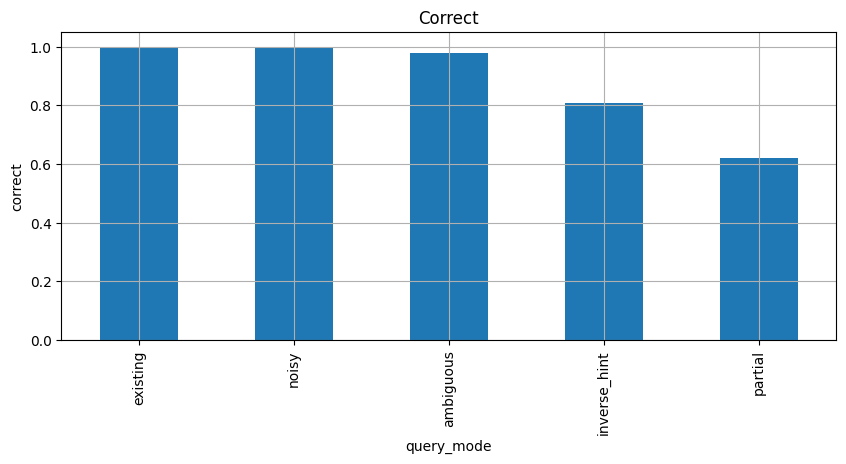

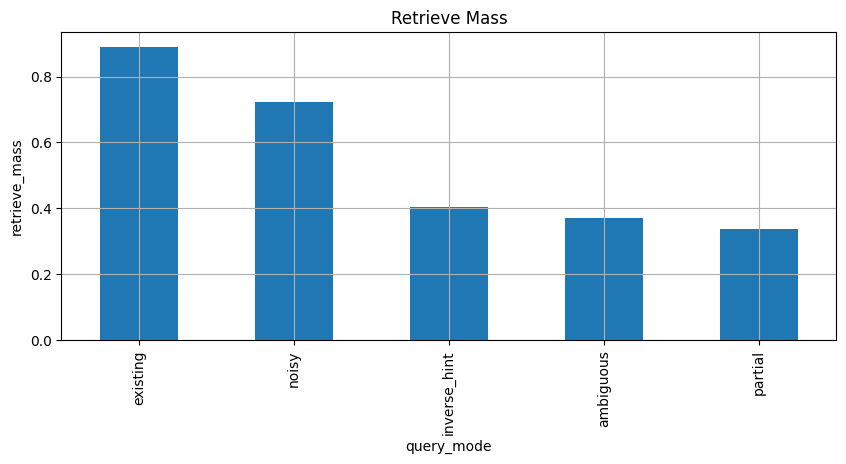

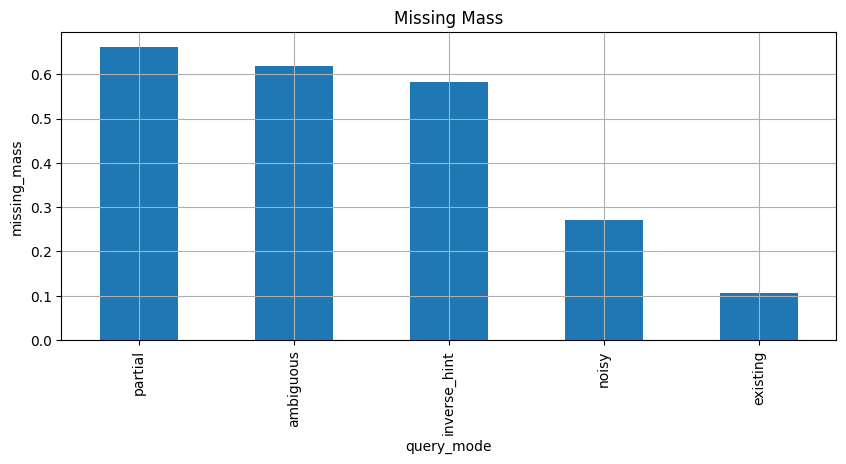

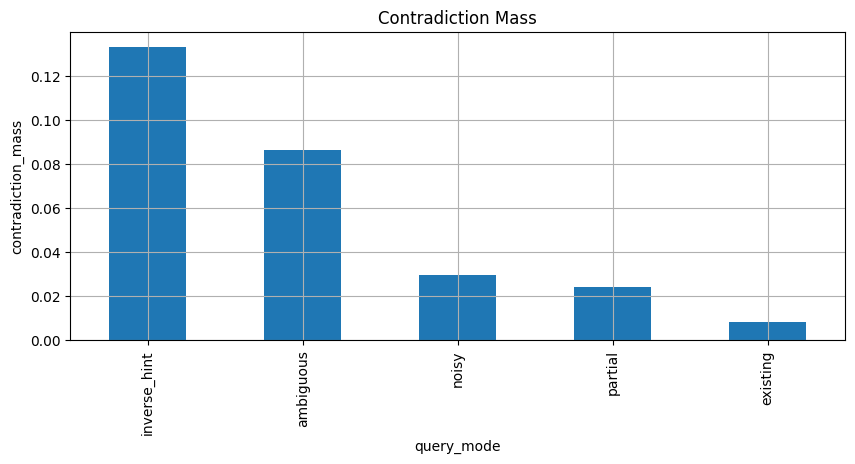

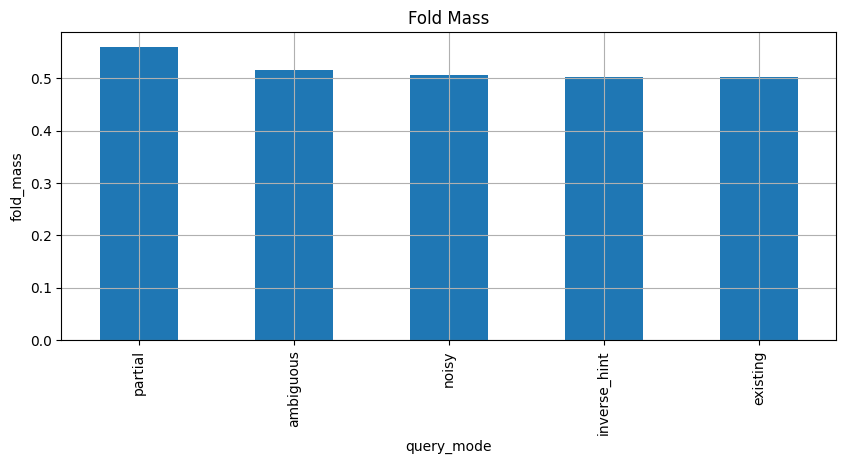

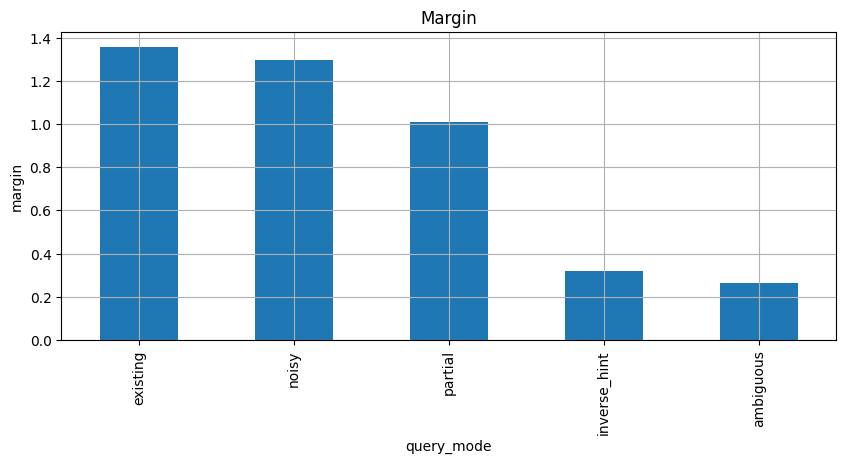

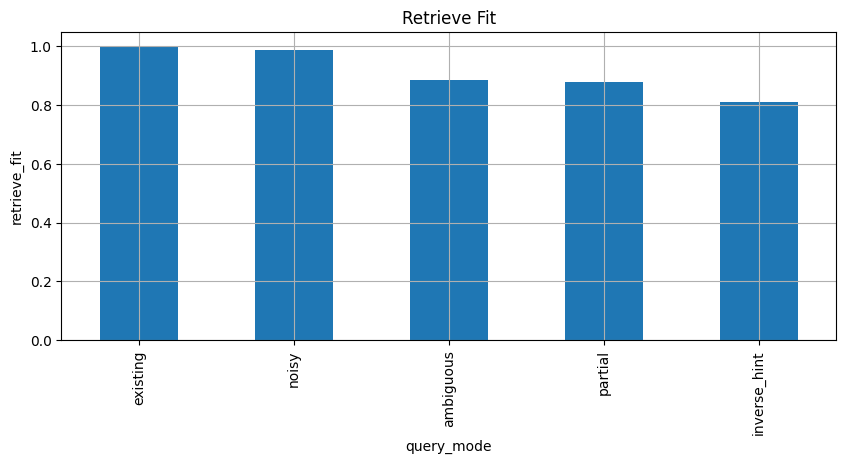

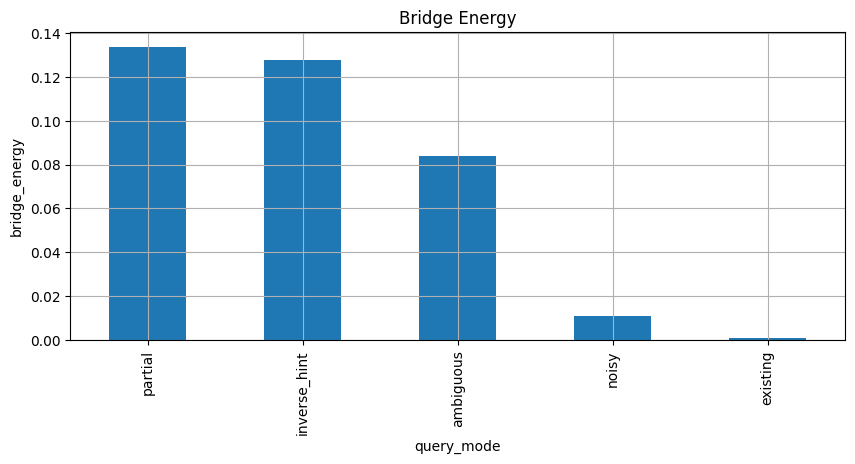

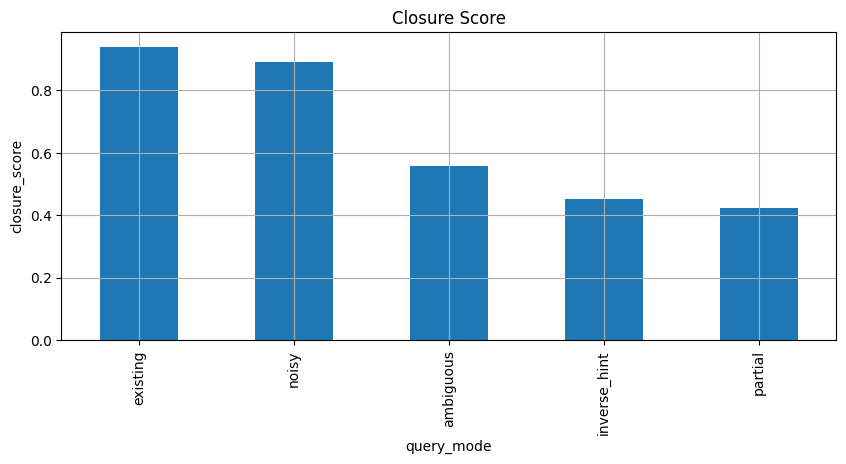

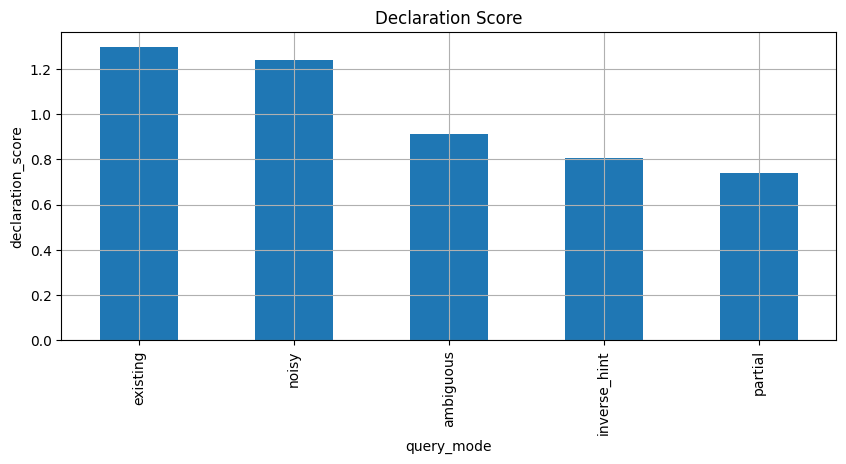

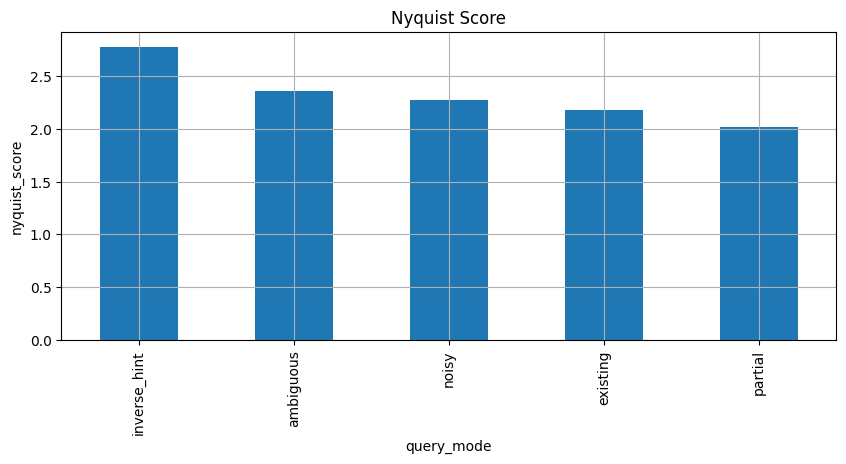

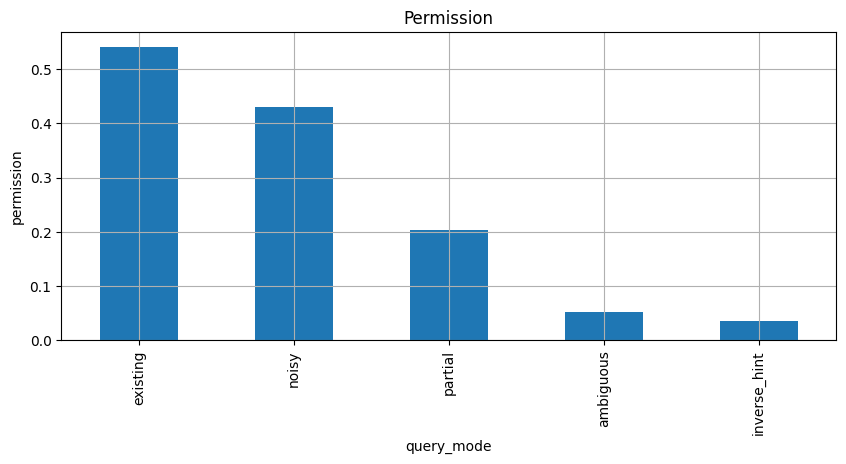

In [16]:

metrics = [
    "correct",
    "retrieve_mass",
    "missing_mass",
    "contradiction_mass",
    "fold_mass",
    "margin",
    "retrieve_fit",
    "bridge_energy",
    "closure_score",
    "declaration_score",
    "nyquist_score",
    "permission",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = field_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


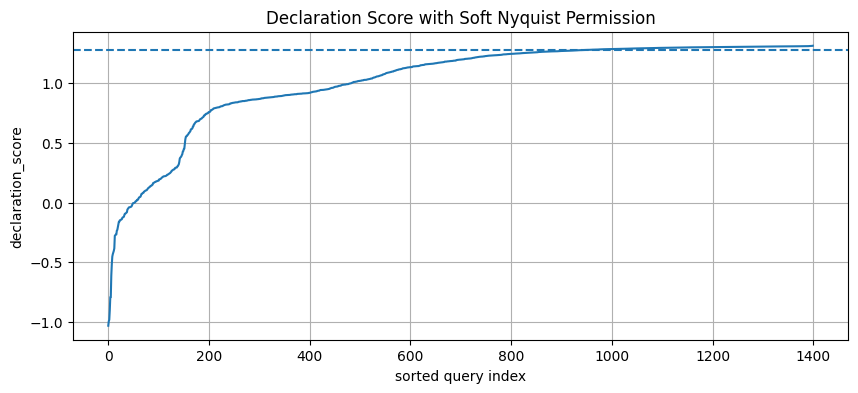

In [17]:

plt.figure(figsize=(10, 4))
score_series = calibrated_eval["declaration_score"].sort_values().reset_index(drop=True)
plt.plot(score_series.values)
plt.axhline(retrieve_threshold, linestyle="--")
plt.title("Declaration Score with Soft Nyquist Permission")
plt.xlabel("sorted query index")
plt.ylabel("declaration_score")
plt.show()



## Practical readout

This notebook keeps the right v29 geometry and fixes the gate law:

- missing remains a directional complement shape
- retrieve becomes soft declaration permission
- Nyquist becomes a score, not an impossible binary wall
- the retrieve branch can return without throwing away the complement math

The runtime object remains:

$$
Q \to (\text{retrieve mask},\ \text{missing mask},\ \text{fold field},\ \text{declared value})
$$

but the controller should now recover a nonzero retrieve branch.
